In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler



In [2]:

X, y=make_blobs(n_samples=500, centers=4, cluster_std=0.70,random_state=42)
df = pd.DataFrame(data=X, columns=["Feature1","Feature2"])
df["Clusters"]=y
print("First 10 rows of the Synthetic Dataset : \n")
print(df)
print("The shape of the dataset : ",df.shape)


First 10 rows of the Synthetic Dataset : 

     Feature1  Feature2  Clusters
0   -8.033836  6.831299         3
1   -8.767448 -6.918116         2
2    6.172741  1.407361         1
3   -2.783673  7.989826         0
4   -6.038777 -7.165762         2
..        ...       ...       ...
495 -7.858779  7.970766         3
496 -2.563169  9.253093         0
497 -7.114676 -5.711795         2
498 -7.245533 -6.145803         2
499  5.003421  3.046087         1

[500 rows x 3 columns]
The shape of the dataset :  (500, 3)


In [3]:
num_cols=["Feature1","Feature2"]
print(df[num_cols].head)
print(df[num_cols].dtypes)

<bound method NDFrame.head of      Feature1  Feature2
0   -8.033836  6.831299
1   -8.767448 -6.918116
2    6.172741  1.407361
3   -2.783673  7.989826
4   -6.038777 -7.165762
..        ...       ...
495 -7.858779  7.970766
496 -2.563169  9.253093
497 -7.114676 -5.711795
498 -7.245533 -6.145803
499  5.003421  3.046087

[500 rows x 2 columns]>
Feature1    float64
Feature2    float64
dtype: object


In [4]:
num_cols=["Feature1","Feature2"]
X_scaled =df.copy()
scaler = StandardScaler()
X_scaled[num_cols] = scaler.fit_transform(X_scaled[num_cols])
print("Scaled data : ")
print(df)
print(df[num_cols].dtypes)


Scaled data : 
     Feature1  Feature2  Clusters
0   -8.033836  6.831299         3
1   -8.767448 -6.918116         2
2    6.172741  1.407361         1
3   -2.783673  7.989826         0
4   -6.038777 -7.165762         2
..        ...       ...       ...
495 -7.858779  7.970766         3
496 -2.563169  9.253093         0
497 -7.114676 -5.711795         2
498 -7.245533 -6.145803         2
499  5.003421  3.046087         1

[500 rows x 3 columns]
Feature1    float64
Feature2    float64
dtype: object


In [5]:
KMeans_model=KMeans(n_clusters=3,random_state=42,n_init=10)
X_scaled["KMeans_Clusters"] = KMeans_model.fit_predict(X_scaled[["Feature1", "Feature2"]])
print("After KMeans Clustering :")
print(X_scaled)



After KMeans Clustering :
     Feature1  Feature2  Clusters  KMeans_Clusters
0   -0.888474  0.629907         3                1
1   -1.028908 -1.562875         2                2
2    1.831069 -0.235113         1                0
3    0.116557  0.814671         0                1
4   -0.506563 -1.602370         2                2
..        ...       ...       ...              ...
495 -0.854963  0.811631         3                1
496  0.158767  1.016139         0                1
497 -0.712520 -1.370489         2                2
498 -0.737570 -1.439705         2                2
499  1.607228  0.026234         1                0

[500 rows x 4 columns]


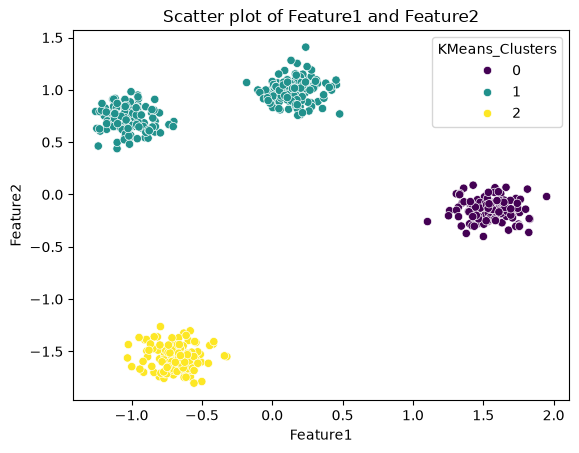

In [6]:
sns.scatterplot(data=X_scaled,x="Feature1",y="Feature2",hue ="KMeans_Clusters",markers="O",palette="viridis")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Scatter plot of Feature1 and Feature2")
plt.show()

In [7]:
inertias = []
k_value = range(1,11)
for k in k_value:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(X_scaled[["Feature1", "Feature2"]])
    inertias.append(kmeans.inertia_)


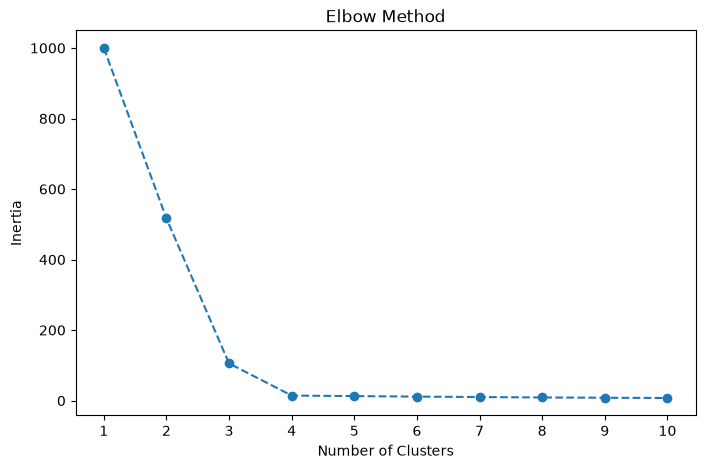

In [8]:
plt.figure(figsize=(8,5))
plt.plot(k_value, inertias,marker ="o",linestyle="--")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(k_value)
plt.show()

In [9]:
KMeans_model=KMeans(n_clusters=4,random_state=42,n_init=10)
X_scaled["KMeans_Clusters"] = KMeans_model.fit_predict(X_scaled[["Feature1", "Feature2"]])
print("After KMeans Clustering :")
print(X_scaled)


After KMeans Clustering :
     Feature1  Feature2  Clusters  KMeans_Clusters
0   -0.888474  0.629907         3                1
1   -1.028908 -1.562875         2                2
2    1.831069 -0.235113         1                0
3    0.116557  0.814671         0                3
4   -0.506563 -1.602370         2                2
..        ...       ...       ...              ...
495 -0.854963  0.811631         3                1
496  0.158767  1.016139         0                3
497 -0.712520 -1.370489         2                2
498 -0.737570 -1.439705         2                2
499  1.607228  0.026234         1                0

[500 rows x 4 columns]


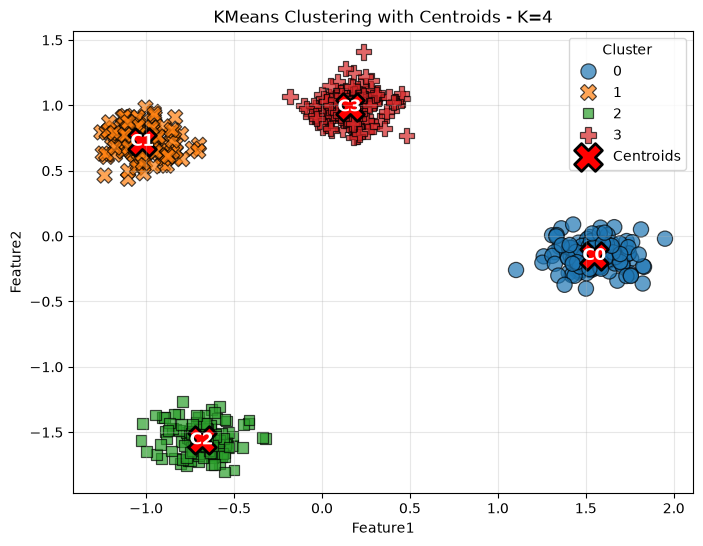

In [10]:
centroids = KMeans_model.cluster_centers_

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=X_scaled,
    x="Feature1", 
    y="Feature2",
    hue="KMeans_Clusters",  
    style="KMeans_Clusters", 
    palette="tab10",
    s=120,
    alpha=0.7,
    edgecolor="black"
)

plt.scatter(
    centroids[:, 0], 
    centroids[:, 1],
    c='red',          
    marker='X',       
    s=400,            
    edgecolor='black',
    linewidth=2,
    label='Centroids'
)

for i, (x, y) in enumerate(centroids):
    plt.text(x, y, f'C{i}', fontsize=12, fontweight='bold', color='white',
             ha='center', va='center')

plt.title("KMeans Clustering with Centroids - K=4")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
df = pd.read_csv("Mall_Customers.csv")
print("First five rows of the Mall Customer Datasets : ")
print(df.head(5))

First five rows of the Mall Customer Datasets : 
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [32]:
X_scaled2 = df.copy()
mall_num_cols = ["Annual Income (k$)","Spending Score (1-100)"]
scaler2 = StandardScaler()
X_scaled2[mall_num_cols] = scaler2.fit_transform(X_scaled2[mall_num_cols])

In [33]:
mall_model = KMeans(n_clusters=3,random_state=42,n_init=10)
X_scaled2["KMeans Clusters"]=mall_model.fit_predict(X_scaled2[mall_num_cols])

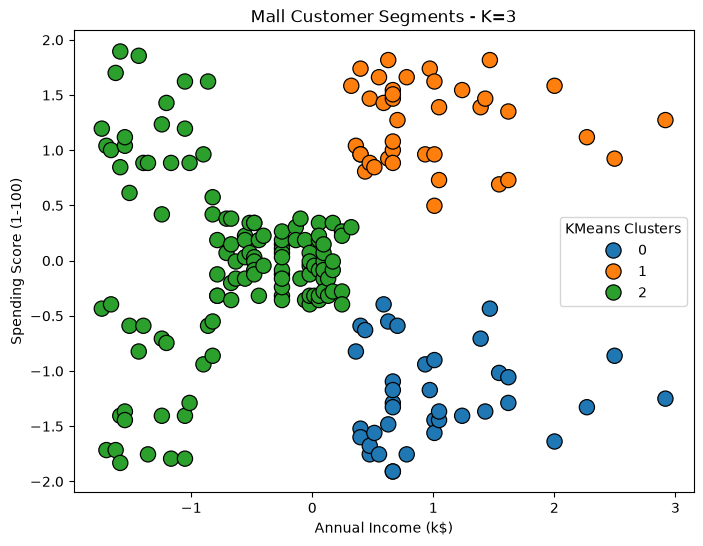

In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=X_scaled2, x="Annual Income (k$)", y="Spending Score (1-100)", hue="KMeans Clusters", palette="tab10", s=120, edgecolor="black")
plt.title("Mall Customer Segments - K=3")
plt.show()

In [35]:
inertias2 = []
k_range = range(1,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(X_scaled2[mall_num_cols])
    inertias2.append(kmeans.inertia_)


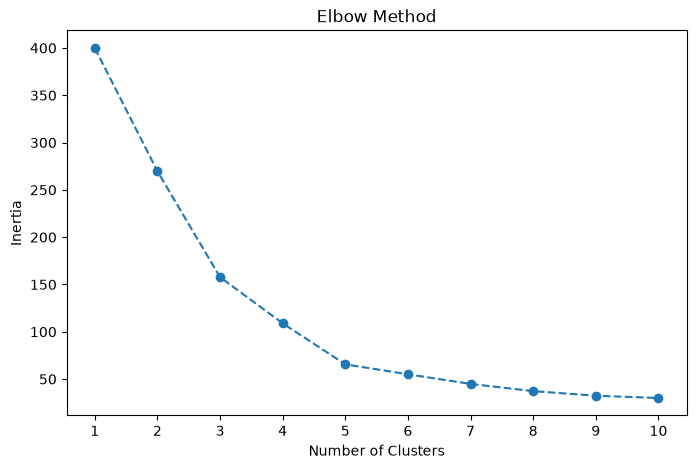

In [36]:
plt.figure(figsize=(8,5))
plt.plot(k_range, inertias2,marker ="o",linestyle="--")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.show()

In [41]:
mall_model = KMeans(n_clusters=5, random_state=42, n_init=10)
X_scaled2["Customer Clusters"] = mall_model.fit_predict(X_scaled2[mall_num_cols])
print("Mall Dataset after opyimal number of clusters : ")
print(X_scaled2)

Mall Dataset after opyimal number of clusters : 
     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0             1    Male   19           -1.738999               -0.434801   
1             2    Male   21           -1.738999                1.195704   
2             3  Female   20           -1.700830               -1.715913   
3             4  Female   23           -1.700830                1.040418   
4             5  Female   31           -1.662660               -0.395980   
..          ...     ...  ...                 ...                     ...   
195         196  Female   35            2.268791                1.118061   
196         197  Female   45            2.497807               -0.861839   
197         198    Male   32            2.497807                0.923953   
198         199    Male   32            2.917671               -1.250054   
199         200    Male   30            2.917671                1.273347   

     KMeans Clusters  Customer Cluster

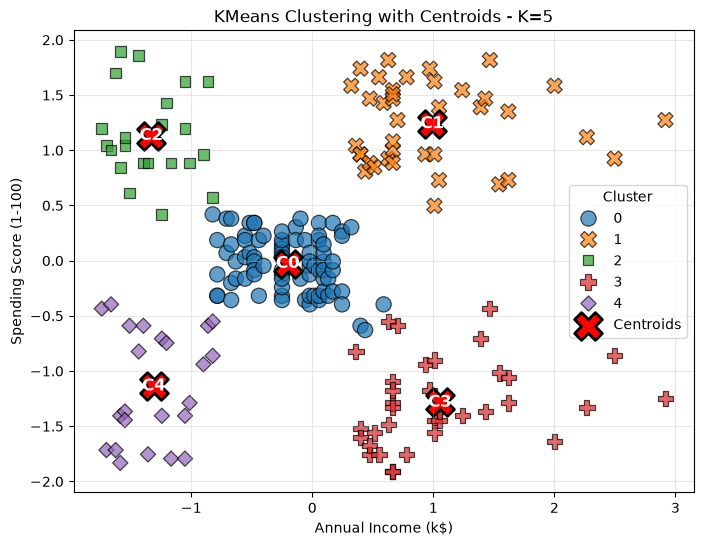

In [44]:
centroids = mall_model.cluster_centers_

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=X_scaled2,
    x="Annual Income (k$)", 
    y="Spending Score (1-100)",
    hue="KMeans_Clusters",  # <-- fixed name
    style="KMeans_Clusters", # <-- fixed name
    palette="tab10",
    s=120,
    alpha=0.7,
    edgecolor="black"
)

plt.scatter(
    centroids[:, 0], 
    centroids[:, 1],
    c='red',          
    marker='X',       
    s=400,            
    edgecolor='black',
    linewidth=2,
    label='Centroids'
)

for i, (x, y) in enumerate(centroids):
    plt.text(x, y, f'C{i}', fontsize=12, fontweight='bold', color='white',
             ha='center', va='center')

plt.title("KMeans Clustering with Centroids - K=5")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.3)
plt.show()